# 53 · The empty-box story: what our signal is (and is not)

Seven short chapters that tell the whole empty-box story, each with the one figure that carries it.

**Data: experiment-24's metal empty box** — the same scene recorded 3 times (recordings 96–98) × 8 speakers, 23 of 24 captures present (sample 000791 = rec 98 × speaker 8 is missing, so speaker 8 has one pair instead of three). The config cell below switches datasets; this notebook was first run on experiment-25 (notebook 52's box), and the contrast is the headline: **several conclusions flip between the two datasets** — flagged per chapter below.

The physical model we test against (Bagon, Kichler & Sheinin, CVPR 2026 — same rig, one lab over):

$$V(x_n, \omega) \;\approx\; \underbrace{\gamma}_{\text{loudness, per capture}} \; \underbrace{\beta_n}_{\text{optics, per laser per capture}} \; \underbrace{P(\omega)}_{\text{chirp × speaker}} \; \underbrace{\sum_k \nabla\varphi_k(x_n) G_k(\omega)}_{\text{the box's modes — the content}} + \; \eta$$

Every nuisance is **multiplicative**, and the content lives only in the modal sum. The story on this dataset:

1. **Magnitude is stable** — reproduces to a median 0.21 dB.
2. **The box has modes — strong ones** — 99 reproducible peaks vs ~3 by coincidence.
3. **Phase survives across recordings** — every method on the scoreboard beats its random baseline (it was uniformly DEAD on experiment-25).
4. **Coherence is genuine here** — the observed tail dwarfs the estimator null (on experiment-25 the null explained everything).
5. **What normalization keeps** — peeling the model's nuisance factors off, layer by layer.
6. **The scoreboard of what works** — magnitude *and* phase, one axis.
7. **The phase payoff** — Eq. 11 mode-shape maps reproduce at r up to 0.94.


In [1]:
import sys
from pathlib import Path

def _find_repo_root(marker='pyproject.toml'):
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / marker).exists(): return candidate
    raise RuntimeError('repo root not found')

REPO_ROOT = _find_repo_root()
for p in (REPO_ROOT, REPO_ROOT / 'src'):
    if str(p) not in sys.path: sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sps
from scipy.ndimage import median_filter

from utils.io_utils import load

# SAMPLES_DIR = Path(r'D:\eturok\experiment-25\samples')
# OUTPUTS = [0, 1, 2]
# PAIRS = [(0, 1), (0, 2), (1, 2)]

SAMPLES_DIR = Path(r'D:\eturok\experiment-24\samples')
OUTPUTS = [96, 97, 98]
PAIRS = [(96, 97), (96, 98), (97, 98)]

SPEAKERS = list(range(1, 9))
COLORS = ['#0072B2', '#E69F00', '#009E73']
OUT_COLORS = {o:c for o, c in zip(OUTPUTS, COLORS)} # Okabe-Ito, fixed hue per recording in every figure
RAW_GRAY, BLUE, RED, GREEN = '#9ca3af', '#0072B2', '#dc2626', '#009E73'
plt.rcParams.update({'figure.dpi': 80, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25})

ffts = {}
for out in OUTPUTS:
    for spk in SPEAKERS:
        p = SAMPLES_DIR / f'{out * 8 + (spk - 1):06d}' / 'vibration/03_fft.npz'
        if p.exists():
            npz = load(p)
            ffts[(out, spk)] = npz['fft'][0]  # (lasers, freqs, x/y), complex64
freqs = npz['freqs']
L, F, C = list(ffts.values())[0].shape

def avail(spk): return [o for o in OUTPUTS if (o, spk) in ffts]
def avail_pairs(spk): return [(o1, o2) for o1, o2 in PAIRS if (o1, spk) in ffts and (o2, spk) in ffts]

print(f'{len(ffts)} captures | lasers={L} freqs={F} ({freqs[0]:.0f}-{freqs[-1]:.0f} Hz) channels={C}')


23 captures | lasers=100 freqs=2946 (50-1000 Hz) channels=2


In [2]:
ffts.keys()

dict_keys([(96, 1), (96, 2), (96, 3), (96, 4), (96, 5), (96, 6), (96, 7), (96, 8), (97, 1), (97, 2), (97, 3), (97, 4), (97, 5), (97, 6), (97, 7), (97, 8), (98, 1), (98, 2), (98, 3), (98, 4), (98, 5), (98, 6), (98, 7)])

In [3]:
# Welch machinery on a 2 Hz grid: PSD per (laser, channel), and cross-spectrum + coherence vs a fixed
# reference laser (the strongest one, per speaker). N_SEG segments of 0.5 s, 50% overlap.
FS, NPERSEG = 2500, 1250
REF_LASER = {spk: int(np.abs(ffts[(96, spk)]).mean(axis=(1, 2)).argmax()) for spk in SPEAKERS}

welch, pxx = {}, {}
for (out, spk) in ffts:
    shifts = np.load(SAMPLES_DIR / f'{out * 8 + (spk - 1):06d}' / 'vibration/02_clean_shifts.npy')[0]  # (L, T, C)
    x = np.moveaxis(shifts, -1, 1)          # (L, C, T)
    ref = x[REF_LASER[spk], 0][None, None]
    fw, G = sps.csd(x, ref, fs=FS, nperseg=NPERSEG, axis=-1)
    _, P = sps.welch(x, fs=FS, nperseg=NPERSEG, axis=-1)
    _, Pr = sps.welch(ref, fs=FS, nperseg=NPERSEG, axis=-1)
    keep = (fw >= 50) & (fw <= 1000)
    welch[(out, spk)] = dict(G=G[..., keep], coh=(np.abs(G) ** 2 / np.maximum(P * Pr, 1e-30))[..., keep])
    pxx[(out, spk)] = P[..., keep]
FW = fw[keep]
N_SEG = (shifts.shape[1] - NPERSEG) // (NPERSEG // 2) + 1
print(f'Welch: df={FW[1] - FW[0]:.1f} Hz, {len(FW)} bins in 50-1000 Hz, {N_SEG} segments (50% overlap), ref lasers {REF_LASER}')


Welch: df=2.0 Hz, 476 bins in 50-1000 Hz, 11 segments (50% overlap), ref lasers {1: 14, 2: 19, 3: 17, 4: 46, 5: 55, 6: 36, 7: 15, 8: 14}


### How Welch slices the capture — and which frequencies land in which segment

Welch's method chops the ~3 s capture into **11 half-overlapping 0.5 s segments**, multiplies each by a Hann window, FFTs each segment onto the 2 Hz grid, and averages the 11 segment spectra per frequency bin.

The figure below makes the slicing concrete for one capture (reference laser, x channel):

- **row 1** — the raw time-domain shift signal. Note the ring-ups: the burst near 2.25 s is the sweep crossing the box's ~384 Hz resonance (chapter 7's strongest mode);
- **row 2** — the 11 Hann windows that cut it (alternating colors; each segment overlaps its neighbors by 50%);
- **row 3** — the spectrogram of the **stimulus** (`audio.wav`): a single *exponential* sweep 50→1000 Hz, so each segment drives only a narrow, rising band of frequencies (segment boundaries in white);
- **row 4** — each segment's own FFT of the **response**, one row per segment, with the band that segment actually *drove* marked in red.

Row 4 answers "which frequencies belong to which segment": each frequency bin is driven in **~1 of the 11 segments** (the red staircase). On this metal box the response actually *tracks* the staircase — bright blobs sit on the red bars where the sweep excites resonances (segment 8 lights up at ~380–430 Hz). Contrast experiment-25, where the same panel was featureless broadband: the driven response was buried under speckle noise in every segment.

Either way, a given 2 Hz bin is coherently driven in at most ~1 of its 11 "averages". A rerun with **repeated chirps (repetition period ≤ 0.5 s)** would put every frequency in every segment — 11 real looks per bin instead of one.


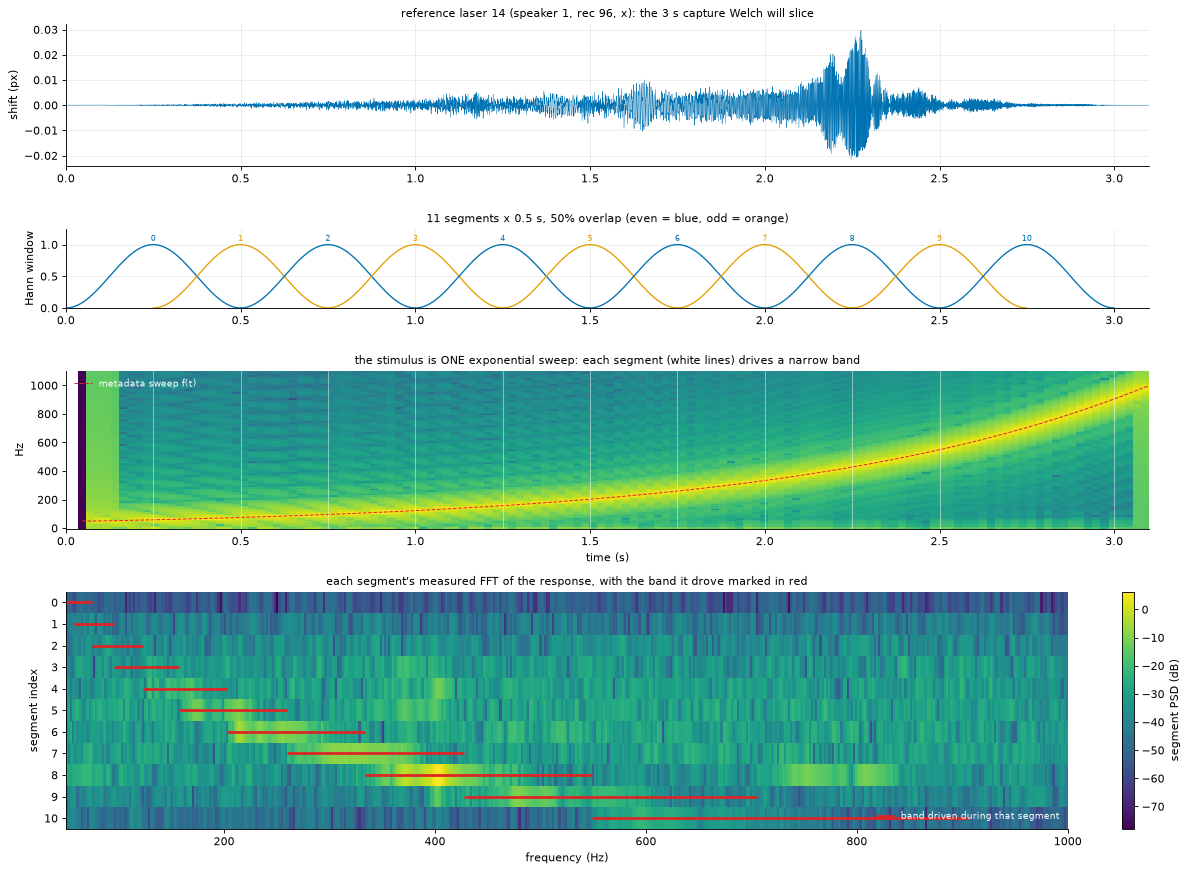

In [4]:
# visualize the Welch segmentation: time trace, the 11 Hann windows, the stimulus sweep, and per-segment FFTs
from scipy.io import wavfile

out, spk = 96, 1
shifts_v = np.load(SAMPLES_DIR / f'{out * 8 + (spk - 1):06d}' / 'vibration/02_clean_shifts.npy')[0]
s = shifts_v[REF_LASER[spk], :, 0]                      # reference laser, x channel
t = np.arange(len(s)) / FS
starts = np.arange(N_SEG) * (NPERSEG // 2)
win = sps.get_window('hann', NPERSEG)

seg_psd = np.stack([np.abs(np.fft.rfft(win * s[st:st + NPERSEG])) ** 2 for st in starts])
fseg = np.fft.rfftfreq(NPERSEG, 1 / FS)
kseg = (fseg >= 50) & (fseg <= 1000)

fs_a, audio = wavfile.read(REPO_ROOT / 'data/audio/chirp_50_1000_3.0sec/audio.wav')
a = (audio[:, 0] if audio.ndim > 1 else audio).astype(float)
fa, ta, Sa = sps.spectrogram(a, fs=fs_a, nperseg=4096, noverlap=3072)
ka = fa <= 1100
def fchirp(tt):  # instantaneous sweep frequency, from the stimulus metadata (exponential, 0.1 s fade-in)
    return np.clip(50 * (1000 / 50) ** ((np.asarray(tt) - 0.1) / 3.0), 50, 1000)

fig, axes = plt.subplots(4, 1, figsize=(15, 11), height_ratios=[0.9, 0.5, 1.0, 1.5])
axes[0].plot(t, s, color=BLUE, lw=0.4)
axes[0].set_ylabel('shift (px)'); axes[0].set_xlim(t[0], t[-1])
axes[0].set_title(f'reference laser {REF_LASER[spk]} (speaker {spk}, rec {out}, x): the 3 s capture Welch will slice', fontsize=10)

for i, st in enumerate(starts):
    c = BLUE if i % 2 == 0 else '#E69F00'
    axes[1].plot(t[st:st + NPERSEG], win, color=c, lw=1.2)
    axes[1].text(t[st + NPERSEG // 2], 1.06, str(i), ha='center', fontsize=7, color=c)
axes[1].set_ylim(0, 1.25); axes[1].set_xlim(t[0], t[-1]); axes[1].set_ylabel('Hann window')
axes[1].set_title(f'{N_SEG} segments x {NPERSEG / FS:.1f} s, 50% overlap (even = blue, odd = orange)', fontsize=10)

axes[2].pcolormesh(ta, fa[ka], 10 * np.log10(np.maximum(Sa[ka], 1e-12)), cmap='viridis', shading='auto')
axes[2].plot(ta, fchirp(ta), color=RED, lw=0.9, ls='--', label='metadata sweep f(t)')
axes[2].legend(frameon=False, fontsize=8, loc='upper left', labelcolor='white')
for st in [*starts, starts[-1] + NPERSEG]:
    axes[2].axvline(st / FS, color='white', lw=0.6, alpha=0.7)
axes[2].set_xlim(t[0], t[-1]); axes[2].set_ylabel('Hz'); axes[2].grid(False); axes[2].set_xlabel('time (s)')
axes[2].set_title('the stimulus is ONE exponential sweep: each segment (white lines) drives a narrow band', fontsize=10)

im = axes[3].imshow(10 * np.log10(np.maximum(seg_psd[:, kseg], 1e-12)), aspect='auto', cmap='viridis',
                    extent=[50, 1000, N_SEG - 0.5, -0.5], interpolation='nearest')
for i, st in enumerate(starts):
    flo, fhi = fchirp(st / FS), fchirp((st + NPERSEG) / FS)
    axes[3].plot([flo, fhi], [i, i], color=RED, lw=2.5, solid_capstyle='butt',
                 label='band driven during that segment' if i == 0 else None)
axes[3].set_xlabel('frequency (Hz)'); axes[3].set_ylabel('segment index'); axes[3].grid(False)
axes[3].set_yticks(range(N_SEG)); axes[3].legend(frameon=False, fontsize=8, loc='lower right', labelcolor='white')
axes[3].set_title("each segment's measured FFT of the response, with the band it drove marked in red", fontsize=10)
fig.colorbar(im, ax=axes[3], fraction=0.025, label='segment PSD (dB)')
fig.tight_layout(); plt.show()


## 1 · Magnitude is stable

The first question for any feature: does it reproduce when we record the *same* scene again?

But first, what does the signal even look like? The panel below shows the **same spectrum** (laser + channel averaged |FFT|, speaker 1, 3 recordings) in three spaces:

- **linear |FFT|** — dominated by the low-frequency rolloff; everything above ~200 Hz is squashed into an unreadable band near zero;
- **log₁₀ |FFT|** — the whole 50–1000 Hz band becomes readable, and the 3 recordings visibly agree everywhere;
- **dB** — *the identical curve*: dB = 20·log₁₀|FFT|, i.e. log magnitude times a constant. Only the axis labels change.

So "log vs dB" is not a choice — they are the same representation; we use dB for familiar units (3 dB = 2× power). "Linear vs log" *is* a choice, and log wins for a second, deeper reason: the forward model is multiplicative, so in log space its nuisance factors become *additive offsets* that later chapters remove by simple subtraction.

Then the reproducibility check proper: the PSD averaged over all 100 lasers × 2 channels (which crushes single-spectrum estimator noise ~14×), in dB, for the 3 recordings of every speaker. **Result: median recording-to-recording gap 0.21 dB (95th percentile 0.76 dB)** — the magnitude spectrum reproduces essentially perfectly, as it did on experiment-25.


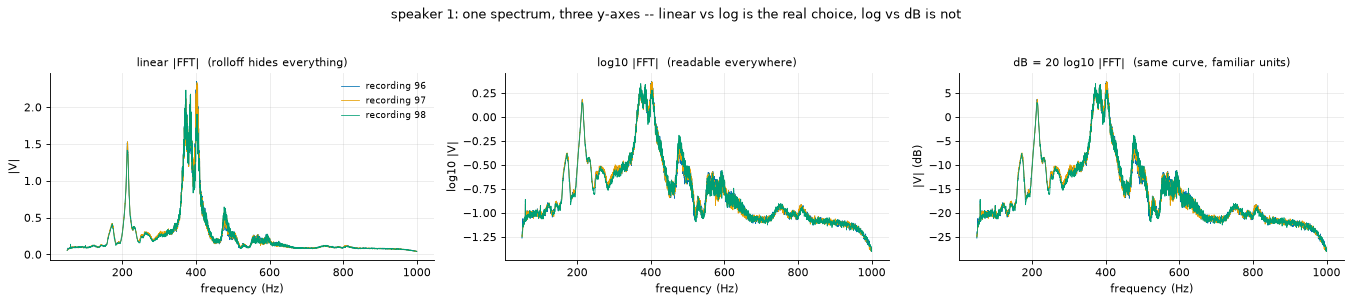

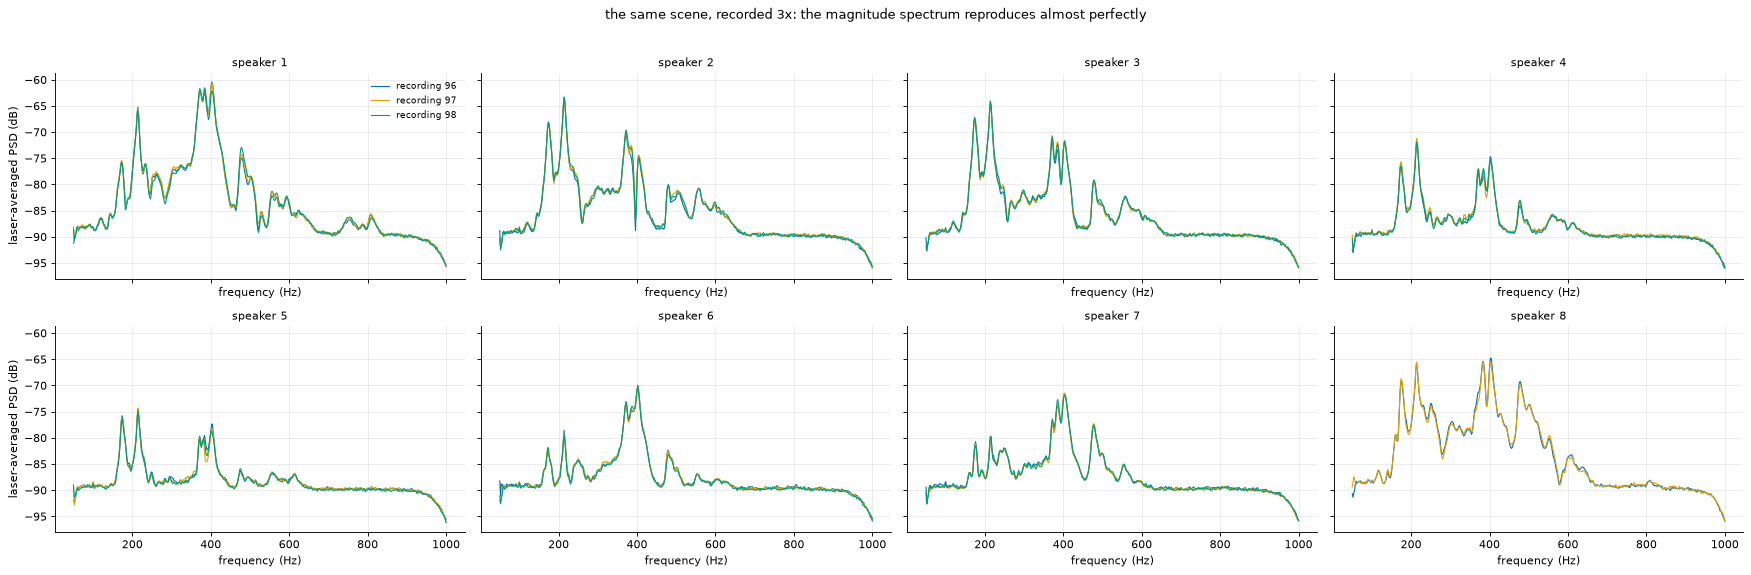

median |recording-to-recording gap|: 0.21 dB   (95th pct: 0.76 dB)


In [5]:
# the same spectrum in three spaces: linear |FFT|, log10 |FFT|, and dB (= 20 log10, identical up to scale)
spk = 1
mag = {out: np.abs(ffts[(out, spk)]).mean(axis=(0, 2)) for out in avail(spk)}  # avg over 100 lasers x 2 channels

fig, axes = plt.subplots(1, 3, figsize=(17, 3.6), sharex=True)
for out in avail(spk):
    axes[0].plot(freqs, mag[out], color=OUT_COLORS[out], lw=0.7, label=f'recording {out}')
    axes[1].plot(freqs, np.log10(mag[out]), color=OUT_COLORS[out], lw=0.7)
    axes[2].plot(freqs, 20 * np.log10(mag[out]), color=OUT_COLORS[out], lw=0.7)
axes[0].set_title('linear |FFT|  (rolloff hides everything)', fontsize=10); axes[0].set_ylabel('|V|')
axes[1].set_title('log10 |FFT|  (readable everywhere)', fontsize=10);       axes[1].set_ylabel('log10 |V|')
axes[2].set_title('dB = 20 log10 |FFT|  (same curve, familiar units)', fontsize=10); axes[2].set_ylabel('|V| (dB)')
for ax in axes: ax.set_xlabel('frequency (Hz)')
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f'speaker {spk}: one spectrum, three y-axes -- linear vs log is the real choice, log vs dB is not', y=1.04)
fig.tight_layout(); plt.show()

avg_db = {k: 10 * np.log10(P.mean(axis=(0, 1))) for k, P in pxx.items()}  # laser+channel-averaged PSD, dB

fig, axes = plt.subplots(2, 4, figsize=(22, 7), sharex=True, sharey=True)
for ax, spk in zip(axes.flat, SPEAKERS):
    for out in avail(spk):
        ax.plot(FW, avg_db[(out, spk)], color=OUT_COLORS[out], lw=1, label=f'recording {out}')
    ax.set_title(f'speaker {spk}', fontsize=10)
    ax.set_xlabel('frequency (Hz)')
for ax in axes[:, 0]: ax.set_ylabel('laser-averaged PSD (dB)')
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle('the same scene, recorded 3x: the magnitude spectrum reproduces almost perfectly', y=1.02)
fig.tight_layout(); plt.show()

gaps = [np.abs(avg_db[(o1, spk)] - avg_db[(o2, spk)]) for spk in SPEAKERS for o1, o2 in avail_pairs(spk)]
print(f'median |recording-to-recording gap|: {np.median(np.concatenate(gaps)):.2f} dB   (95th pct: {np.percentile(np.concatenate(gaps), 95):.2f} dB)')


## 2 · The box has modes — strong ones, and a null test sizes them

A modal structure should put resonant bumps on the averaged spectra. We detect peaks on the residual after removing a 61-bin median-filtered background, and demand each peak appear in **all recordings** of that speaker (±1 Welch bin).

The trap (which bit us on experiment-25): with dozens of detected peaks per recording and a ±2 Hz tolerance, *random* peak sets also "reproduce". So every count is compared against a **circular-shift null** — rigidly rotate the other recordings' peak lists by a random frequency offset and re-count. Only the excess over that null is evidence.

**Result: 99 reproducible peaks vs ~3 expected by coincidence — 10–35σ excess for every speaker.** These are real, strong resonances, and the same families recur across speakers: **214 Hz appears for all 8 speakers**, with clusters near 100, 118, 174, 250, 372, 404, 478 and 558 Hz — exactly what shared structural modes of the metal box should look like (different speakers excite the same modes with different strengths). In Bagon et al.'s terms, this box *knocks*. Contrast experiment-25: ~3 weak (0.5–1 dB) peaks per speaker, provable only in aggregate.


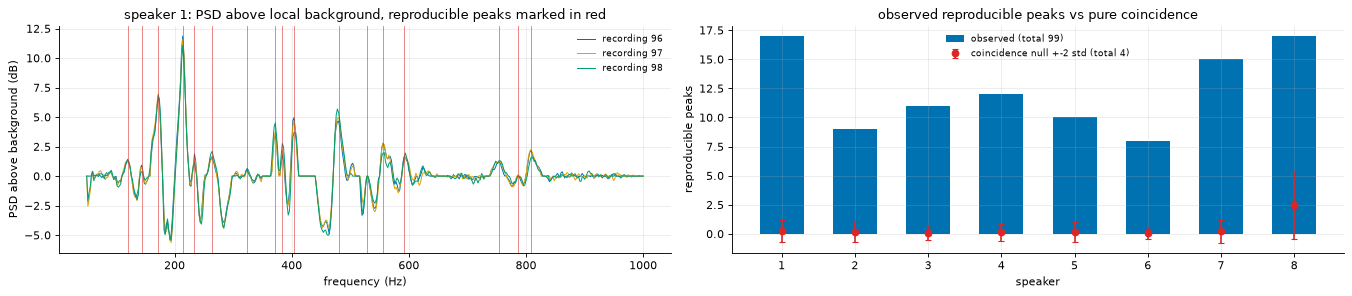

,speaker,observed,chance,excess_sigma,peak_freqs_hz
0,1,17,0.2,35.2,"[120, 144, 172, 214, 234, 264, 324, 372, 384, ..."
1,2,9,0.2,19.9,"[60, 120, 174, 214, 370, 416, 480, 558, 598]"
2,3,11,0.1,33.7,"[118, 174, 214, 268, 296, 370, 386, 404, 478, ..."
3,4,12,0.1,32.4,"[100, 118, 174, 214, 248, 266, 294, 324, 372, ..."
4,5,10,0.2,23.1,"[100, 174, 214, 250, 298, 372, 404, 476, 556, ..."
5,6,8,0.1,30.2,"[100, 172, 214, 252, 372, 402, 478, 552]"
6,7,15,0.2,29.7,"[60, 100, 120, 176, 192, 214, 250, 312, 356, 3..."
7,8,17,2.4,10.0,"[90, 118, 140, 160, 174, 214, 252, 304, 324, 3..."


In [6]:
def peak_freqs(curve_db, grid, bg_bins, prom_db, min_dist_hz):
    resid = curve_db - median_filter(curve_db, size=bg_bins, mode='nearest')
    idx, _ = sps.find_peaks(resid, prominence=prom_db, distance=max(1, int(min_dist_hz / (grid[1] - grid[0]))))
    return grid[idx], resid

peaks, resids = {}, {}
for k, curve in avg_db.items():
    peaks[k], resids[k] = peak_freqs(curve, FW, 31, 0.5, 4)

def reproducible(spk, tol_hz=2.1):
    outs = avail(spk)
    return [f for f in peaks[(outs[0], spk)] if all(np.any(np.abs(peaks[(o, spk)] - f) <= tol_hz) for o in outs[1:])]

def null_repro(spk, tol_hz=2.1, n=300, seed=0):
    # rigidly rotate the OTHER recordings' peak lists by one random offset each, re-count matches
    rng = np.random.default_rng(seed + spk)
    outs, lo, hi = avail(spk), FW[0], FW[-1]
    base, counts = peaks[(outs[0], spk)], []
    for _ in range(n):
        shifted = {o: lo + (peaks[(o, spk)] - lo + rng.uniform(0, hi - lo)) % (hi - lo) for o in outs[1:]}
        counts.append(sum(all(np.any(np.abs(shifted[o] - f) <= tol_hz) for o in outs[1:]) for f in base))
    return float(np.mean(counts)), float(np.std(counts))

repro = {spk: reproducible(spk) for spk in SPEAKERS}
nulls = {spk: null_repro(spk) for spk in SPEAKERS}

spk_show = max(SPEAKERS, key=lambda s: len(repro[s]))
fig, axes = plt.subplots(1, 2, figsize=(17, 3.8))
for out in avail(spk_show):
    axes[0].plot(FW, resids[(out, spk_show)], color=OUT_COLORS[out], lw=0.9, label=f'recording {out}')
for f in repro[spk_show]:
    axes[0].axvline(f, color=RED, lw=0.8, alpha=0.6)
axes[0].set_xlabel('frequency (Hz)'); axes[0].set_ylabel('PSD above background (dB)')
axes[0].set_title(f'speaker {spk_show}: PSD above local background, reproducible peaks marked in red')
axes[0].legend(frameon=False, fontsize=8)
obs = np.array([len(repro[spk]) for spk in SPEAKERS])
mu = np.array([nulls[spk][0] for spk in SPEAKERS]); sd = np.array([max(nulls[spk][1], 1e-9) for spk in SPEAKERS])
axes[1].bar(SPEAKERS, obs, color=BLUE, width=0.6, label=f'observed (total {obs.sum()})')
axes[1].errorbar(SPEAKERS, mu, yerr=2 * sd, fmt='o', color=RED, capsize=3, label=f'coincidence null +-2 std (total {mu.sum():.0f})')
axes[1].set_xlabel('speaker'); axes[1].set_ylabel('reproducible peaks')
axes[1].set_title('observed reproducible peaks vs pure coincidence')
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()
pd.DataFrame([dict(speaker=spk, observed=len(repro[spk]), chance=round(nulls[spk][0], 1),
                   excess_sigma=round((len(repro[spk]) - nulls[spk][0]) / max(nulls[spk][1], 1e-9), 1),
                   peak_freqs_hz=[round(f) for f in repro[spk]]) for spk in SPEAKERS])


## 3 · Does phase survive across recordings? Here — yes, decisively

On experiment-25, each capture re-randomized the laser speckle and cross-recording phase was pure noise; this chapter's scoreboard was invented there to prove that death honestly. Run on experiment-24, **the same scoreboard says the opposite: phase survives.**

The score is amplitude-weighted phase alignment between two recordings of the same scene: $A = |\sum_i x_i| / \sum_i |x_i|$ where $x_i = X^{(1)}_i \overline{X^{(2)}_i}$ over all (laser, frequency, channel) cells. A = 1 means phases agree everywhere; the **random baseline** is not 0 but $\sqrt{\sum w_i^2}/\sum w_i$ (what random phases with the same weights would score) — computed per method, because weight concentration can fake a high score (on experiment-25 it manufactured a fake 0.99).

| method | what it was designed to test | exp-24 score (baseline) | exp-25 score |
|---|---|---|---|
| raw per-bin phase | are captures phase-locked as-is? | **0.727** (0.006) | 0.008 — dead |
| per-frequency referencing (rung 3) | one phase offset per frequency (trigger jitter) | 0.739 (0.006) | 0.033 — dead |
| per-laser referencing (rung 2) | one constant speckle offset per laser | 0.225 (0.006) | 0.007 — dead |
| rung-2 ceiling | best ANY per-laser rotation could do | 0.744 | 0.056 |
| x/y relative phase | does the motion-ellipse orientation survive? | 0.661 (0.024) | 0.037 — dead |
| Welch cross-spectral phase | does 11-segment averaging rescue relative phase? | **0.821** (0.036) | 0.029 — dead |
| coherence-gated, amplitude-weighted | phase in high-coherence cells | 0.900 | 0.987 — fake |
| coherence-gated, unweighted | same, without the weighting trick | **0.432** over **123,913 cells** (0.003) | 0.106 over 55 cells — random |
| complex empty-diff survival | can the empty box be subtracted in ℂ? | 0.660 (0.592) | 0.581 (0.577) — invalid |

Two instructive wrinkles. First, **the rescue transforms designed for dead phase now *hurt***: per-laser referencing (0.225) destroys alignment that raw phase (0.727) already has, and raw sits essentially at the rung-2 ceiling (0.744) — when phase is locked, don't touch it. Second, the amplitude-weighted gated score (0.900) is *real this time*: on experiment-25 the same statistic was three cells wearing a trench coat; here the unweighted 0.432 over 124k cells backs it up.

First, the one-look diagnostic: cross-recording phasors of 4000 random (unweighted) cells. Mean resultant 0.296 vs ≈0.016 for uniform phases — visible partial locking even without amplitude weighting; the brightest cells (which dominate the weighted scores) lock hardest.


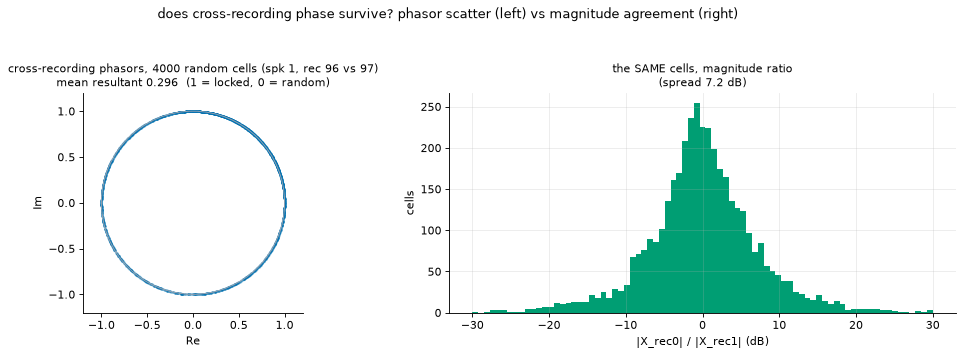

In [7]:
rng = np.random.default_rng(1)
spk = 1
o1, o2 = avail(spk)[:2]
a, b = ffts[(o1, spk)], ffts[(o2, spk)]
idx = (rng.integers(L, size=4000), rng.integers(F, size=4000), rng.integers(C, size=4000))
z = a[idx] * np.conj(b[idx]); z = z / np.maximum(np.abs(z), 1e-30)
ratio_db = 20 * np.log10(np.abs(a[idx]) / np.maximum(np.abs(b[idx]), 1e-30))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].scatter(z.real, z.imag, s=2, alpha=0.15, color=BLUE)
axes[0].add_patch(plt.Circle((0, 0), 1, fill=False, color=RAW_GRAY, lw=0.8))
axes[0].set_aspect('equal'); axes[0].set_xlim(-1.2, 1.2); axes[0].set_ylim(-1.2, 1.2); axes[0].grid(False)
axes[0].set_title(f'cross-recording phasors, 4000 random cells (spk {spk}, rec {o1} vs {o2})\nmean resultant {np.abs(z.mean()):.3f}  (1 = locked, 0 = random)', fontsize=10)
axes[0].set_xlabel('Re'); axes[0].set_ylabel('Im')
axes[1].hist(ratio_db, bins=np.linspace(-30, 30, 80), color=GREEN)
axes[1].set_xlabel('|X_rec0| / |X_rec1| (dB)'); axes[1].set_ylabel('cells')
axes[1].set_title(f'the SAME cells, magnitude ratio\n(spread {np.std(ratio_db):.1f} dB)', fontsize=10)
fig.suptitle('does cross-recording phase survive? phasor scatter (left) vs magnitude agreement (right)', y=1.05)
fig.tight_layout(); plt.show()


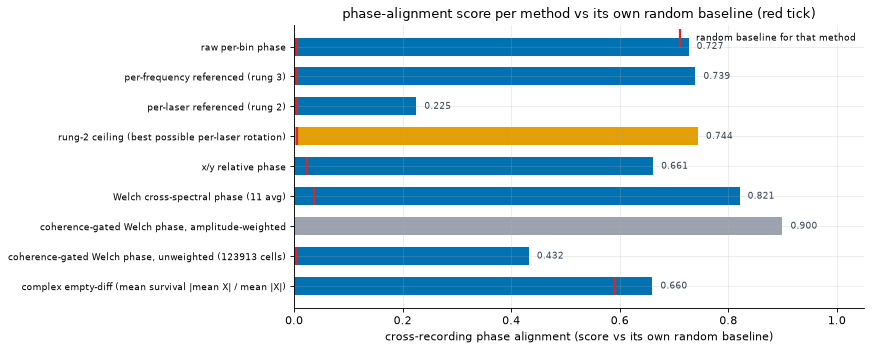

,method,score,random_baseline,verdict
0,raw per-bin phase,0.727,0.006,signal
1,per-frequency referenced (rung 3),0.739,0.006,signal
2,per-laser referenced (rung 2),0.225,0.006,signal
3,rung-2 ceiling (best possible per-laser rotation),0.744,0.006,upper bound
4,x/y relative phase,0.661,0.024,signal
5,Welch cross-spectral phase (11 avg),0.821,0.036,signal
6,"coherence-gated Welch phase, amplitude-weighted",0.900,NaN,see unweighted row
7,"coherence-gated Welch phase, unweighted (12391...",0.432,0.003,signal
8,complex empty-diff (mean survival |mean X| / m...,0.660,0.592,signal


In [8]:
# the scoreboard: every phase method, its alignment score, and ITS OWN random baseline sqrt(sum w^2)/sum w
def alignment(x): return float(np.abs(x.sum()) / max(np.abs(x).sum(), 1e-12))
def baseline(x):
    w = np.abs(x); return float(np.sqrt((w ** 2).sum()) / max(w.sum(), 1e-12))
def xprod(a, b): return a.astype(np.complex128) * np.conj(b.astype(np.complex128))
def ref3(x): return x * np.exp(-1j * np.angle(x.sum(axis=0, keepdims=True)))            # one rotation per (freq, ch)
def ref2(x): return x * np.exp(-1j * np.angle((x * np.abs(x)).sum(axis=1, keepdims=True)))  # one rotation per (laser, ch)
def xy(x): return x[..., 0] * np.conj(x[..., 1])

acc = {}
def add(name, s, b): acc.setdefault(name, [[], []])[0].append(s); acc[name][1].append(b)

gnum = gden = 0.0; gunit = []
for spk in SPEAKERS:
    for o1, o2 in avail_pairs(spk):
        a, b = ffts[(o1, spk)], ffts[(o2, spk)]
        x = xprod(a, b)
        add('raw per-bin phase', alignment(x), baseline(x))
        xr = xprod(ref3(a), ref3(b));            add('per-frequency referenced (rung 3)', alignment(xr), baseline(xr))
        x2 = xprod(ref2(a), ref2(b));            add('per-laser referenced (rung 2)', alignment(x2), baseline(x2))
        add('rung-2 ceiling (best possible per-laser rotation)', float(np.abs(x.sum(axis=1)).sum() / max(np.abs(x).sum(), 1e-12)), baseline(x))
        xx = xy(a.astype(np.complex128)) * np.conj(xy(b.astype(np.complex128)))
        add('x/y relative phase', alignment(xx), baseline(xx))
        Ga, Gb, ca, cb = welch[(o1, spk)]['G'], welch[(o2, spk)]['G'], welch[(o1, spk)]['coh'], welch[(o2, spk)]['coh']
        g = Ga * np.conj(Gb); g = g.copy(); g[REF_LASER[spk], 0] = 0
        add('Welch cross-spectral phase (11 avg)', alignment(g), baseline(g))
        m = (ca > 0.6) & (cb > 0.6); m[REF_LASER[spk], 0] = False
        gm = g[m]; gnum += np.abs(gm.sum()); gden += np.abs(gm).sum(); gunit.append(gm / np.maximum(np.abs(gm), 1e-30))

gunit = np.concatenate(gunit)
rows = [dict(method=k, score=float(np.mean(v[0])), random_baseline=float(np.mean(v[1]))) for k, v in acc.items()]
rows.append(dict(method='coherence-gated Welch phase, amplitude-weighted', score=gnum / max(gden, 1e-12),
                 random_baseline=baseline(np.concatenate([welch[(OUTPUTS[0], s)]['G'][(welch[(OUTPUTS[0], s)]['coh'] > 0.6)] for s in SPEAKERS if (OUTPUTS[0], s) in welch] or [np.array([1.0])]))))
rows[-1]['random_baseline'] = np.nan  # weight concentration makes the analytic baseline the point of the next row
rows.append(dict(method=f'coherence-gated Welch phase, unweighted ({len(gunit)} cells)', score=alignment(gunit), random_baseline=1 / np.sqrt(max(len(gunit), 1))))

surv, surv_null = [], []
rng = np.random.default_rng(2)
for spk in SPEAKERS:
    stack = np.stack([ffts[(o, spk)] for o in avail(spk)]).astype(np.complex64)
    surv.append(float((np.abs(stack.mean(0)) / np.maximum(np.abs(stack).mean(0), 1e-30)).mean()))
    null = np.abs(stack) * np.exp(1j * rng.uniform(0, 2 * np.pi, stack.shape))
    surv_null.append(float((np.abs(null.mean(0)) / np.maximum(np.abs(null).mean(0), 1e-30)).mean()))
rows.append(dict(method='complex empty-diff (mean survival |mean X| / mean |X|)', score=float(np.mean(surv)), random_baseline=float(np.mean(surv_null))))

score_df = pd.DataFrame(rows)
score_df['verdict'] = np.where(score_df.score - score_df.random_baseline.fillna(0) < 0.05, 'DEAD', 'signal')
score_df.loc[score_df.random_baseline.isna(), 'verdict'] = 'see unweighted row'
score_df.loc[score_df.method.str.startswith('rung-2 ceiling'), 'verdict'] = 'upper bound'  # a bound on rung 2, not a method itself

fig, ax = plt.subplots(figsize=(11, 4.5))
y = np.arange(len(score_df))[::-1]
bar_color = {'DEAD': RAW_GRAY, 'upper bound': '#E69F00', 'signal': BLUE, 'see unweighted row': RAW_GRAY}
ax.barh(y, score_df.score, color=[bar_color[v] for v in score_df.verdict], height=0.6)
ax.plot(score_df.random_baseline, y, '|', color=RED, ms=16, mew=2, label='random baseline for that method')
for yi, (s, v) in zip(y, zip(score_df.score, score_df.verdict)):
    ax.text(min(s + 0.015, 0.98), yi, f'{s:.3f}', va='center', fontsize=8, color='#374151')
ax.set_yticks(y); ax.set_yticklabels(score_df.method, fontsize=8)
ax.set_xlim(0, 1.05); ax.set_xlabel('cross-recording phase alignment (score vs its own random baseline)')
ax.set_title('phase-alignment score per method vs its own random baseline (red tick)')
ax.legend(frameon=False, fontsize=8, loc='upper right')
fig.tight_layout(); plt.show()
score_df.round(3)


## 4 · Coherence estimates need a null — and here the tail is real

Within-capture coherence (each cell vs the reference laser) is only trustworthy against the estimator's own noise floor: with ~11 Welch segments, under the no-coherence null $P(\hat C > c) = (1-c)^{n-1}$, so 2.8% of cells exceed 0.3 by pure luck. On experiment-25 the observed histogram *hugged* that null — "high-coherence cells" were flukes, and gating on them was self-deception.

**Here the tail is overwhelmingly real:**

| threshold | observed | estimator null |
|---|---|---|
| coh > 0.3 | 28.1% | 2.8% |
| coh > 0.4 | 19.4% | 0.6% |
| coh > 0.5 | 14.0% | 0.10% |
| coh > 0.6 | 10.5% | 0.01% |

Roughly one cell in seven carries genuine within-capture coherence at this excitation — which is exactly why the coherence-gated phase methods in chapter 3 have 123,913 cells to work with instead of experiment-25's 55. The lesson survives the flip: the histogram-vs-null overlay, not the coherence value itself, is what tells you whether selection is finding signal or noise.


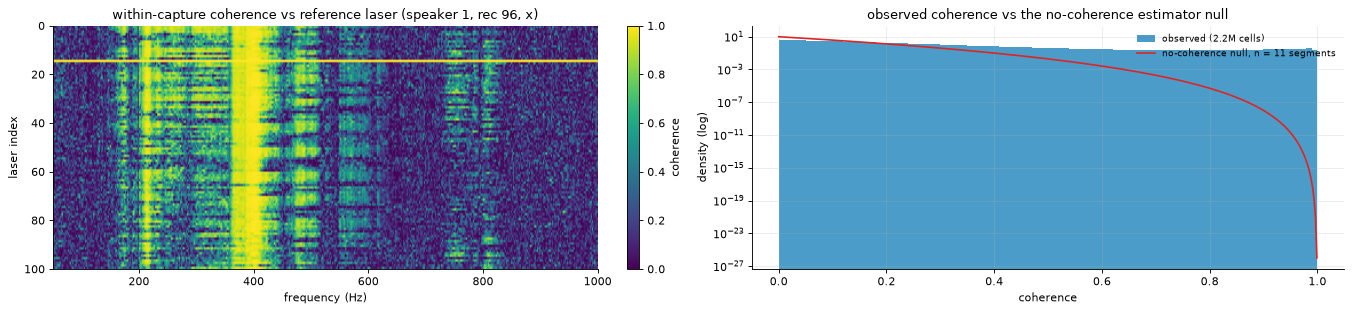

fraction of cells above threshold -- observed vs pure estimator noise:
  coh > 0.3: observed 28.065%   null  2.825%
  coh > 0.4: observed 19.356%   null  0.605%
  coh > 0.5: observed 14.010%   null  0.098%
  coh > 0.6: observed 10.498%   null  0.010%


In [9]:
pool = []
for (out, spk), w in welch.items():
    keepm = np.ones(w['coh'].shape, bool); keepm[REF_LASER[spk], 0] = False
    pool.append(w['coh'][keepm])
pool = np.concatenate(pool)

fig, axes = plt.subplots(1, 2, figsize=(17, 4))
im = axes[0].imshow(welch[(OUTPUTS[0], 1)]['coh'][:, 0, :], aspect='auto', cmap='viridis', vmin=0, vmax=1, extent=[FW[0], FW[-1], L, 0])
axes[0].set_title(f'within-capture coherence vs reference laser (speaker 1, rec {OUTPUTS[0]}, x)'); axes[0].grid(False)
axes[0].set_xlabel('frequency (Hz)'); axes[0].set_ylabel('laser index')
fig.colorbar(im, ax=axes[0], fraction=0.03, label='coherence')
cgrid = np.linspace(0, 0.999, 400)
axes[1].hist(pool, bins=100, density=True, color=BLUE, alpha=0.7, label=f'observed ({len(pool) / 1e6:.1f}M cells)')
axes[1].plot(cgrid, (N_SEG - 1) * (1 - cgrid) ** (N_SEG - 2), color=RED, lw=1.5, label=f'no-coherence null, n = {N_SEG} segments')
axes[1].set_yscale('log'); axes[1].set_xlabel('coherence'); axes[1].set_ylabel('density (log)')
axes[1].set_title('observed coherence vs the no-coherence estimator null')
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()

print('fraction of cells above threshold -- observed vs pure estimator noise:')
for t in (0.3, 0.4, 0.5, 0.6):
    print(f'  coh > {t}: observed {100 * (pool > t).mean():6.3f}%   null {100 * (1 - t) ** (N_SEG - 1):6.3f}%')


## 5 · What normalization keeps — peeling the model's factors off

The forward model says the measured log-PSD is a sum: content + per-laser offset ($\beta_n$) + per-frequency offset ($P(\omega)G(\omega)$ shared shape) + per-capture constant ($\gamma$). The four rows below peel these off one at a time for the 3 recordings of one speaker — the question at each stage is whether the *residual* still looks the same across recordings.

Note the tension this dataset exposes (quantified in chapter 6): on a box with strong shared modes, the per-frequency mean is **not pure nuisance** — it contains the modal resonance structure itself. Removing it strips real, reproducible signal along with the chirp/speaker envelope. Centering choices that were free on experiment-25 have a cost here.


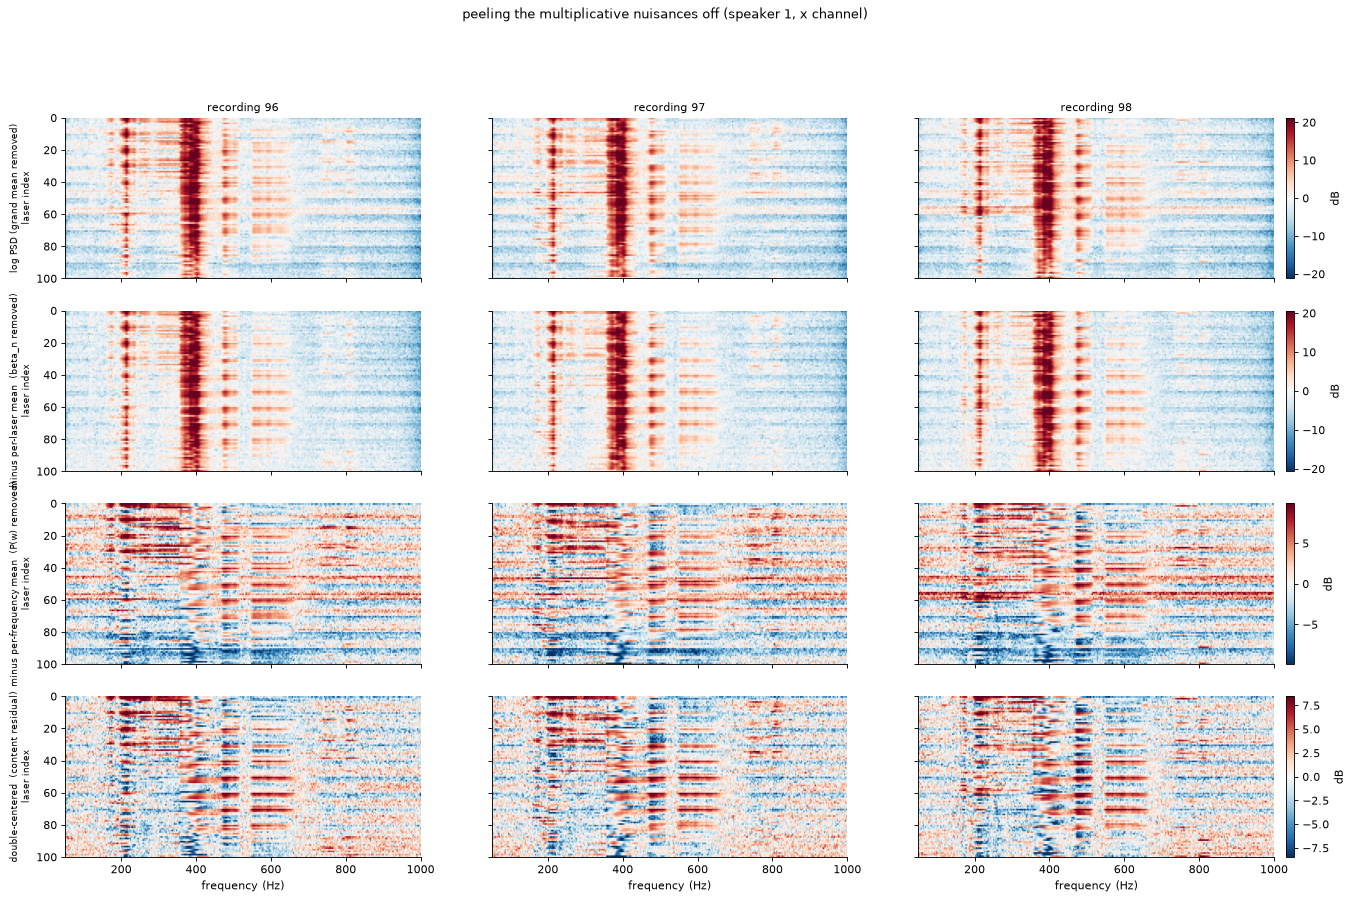

In [10]:
spk, ch = 1, 0
X = {out: 10 * np.log10(pxx[(out, spk)][:, ch, :]) for out in avail(spk)}
stages = [('log PSD (grand mean removed)', lambda D: D - D.mean()),
          ('minus per-laser mean  (beta_n removed)', lambda D: D - D.mean(axis=1, keepdims=True)),
          ('minus per-frequency mean  (P(w) removed)', lambda D: D - D.mean(axis=0, keepdims=True)),
          ('double-centered  (content residual)', lambda D: D - D.mean(axis=1, keepdims=True) - D.mean(axis=0, keepdims=True) + D.mean())]
fig, axes = plt.subplots(4, 3, figsize=(20, 12), sharex=True, sharey=True)
for i, (name, fn) in enumerate(stages):
    Ds = {out: fn(X[out]) for out in avail(spk)}
    vmax = np.percentile(np.abs(np.stack(list(Ds.values()))), 99)
    for j, out in enumerate(avail(spk)):
        im = axes[i, j].imshow(Ds[out], aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax, extent=[FW[0], FW[-1], L, 0])
        axes[i, j].grid(False)
        if i == 0: axes[i, j].set_title(f'recording {out}', fontsize=10)
        if j == 0: axes[i, j].set_ylabel(f'{name}\nlaser index', fontsize=8)
    fig.colorbar(im, ax=axes[i, :], fraction=0.015, pad=0.01, label='dB')
for j in range(3): axes[-1, j].set_xlabel('frequency (Hz)')
fig.suptitle(f'peeling the multiplicative nuisances off (speaker {spk}, x channel)', y=0.995)
plt.show()


## 6 · The scoreboard of what works

Cross-recording Pearson r of magnitude representations (same scene, averaged over speakers and recording pairs), stacked above the phase scoreboard on one axis:

| variant | exp-24 r | exp-25 r |
|---|---|---|
| linear PSD | 0.835 | 0.835 |
| log PSD (dB) | **0.846** | **0.961** |
| log − per-laser mean | 0.843 | 0.894 |
| log − per-frequency mean | 0.621 | 0.930 |
| log double-centered (content residual) | **0.521 ± 0.074** | 0.249 ± 0.007 |

Three readings. (1) Log still ≥ linear, but the log win is small here — this box's reproducibility is not bottlenecked by the spectral tilt. (2) The double-centered **content channel is twice as strong as experiment-25's** (r = 0.52 vs 0.25): after removing everything the model calls nuisance, half the residual variance is stable laser × frequency structure. (3) Unlike experiment-25, removing the per-frequency mean *costs* reproducibility (0.846 → 0.621): the shared modal spectrum lives in that mean, so aggressive centering throws away real signal on a strongly modal box.

And the phase panel below it is no longer a graveyard: every phase method clears its baseline (chapter 3), so on this dataset a model could legitimately be fed complex or mag+phase features — something notebook 52 ruled out for experiment-25.


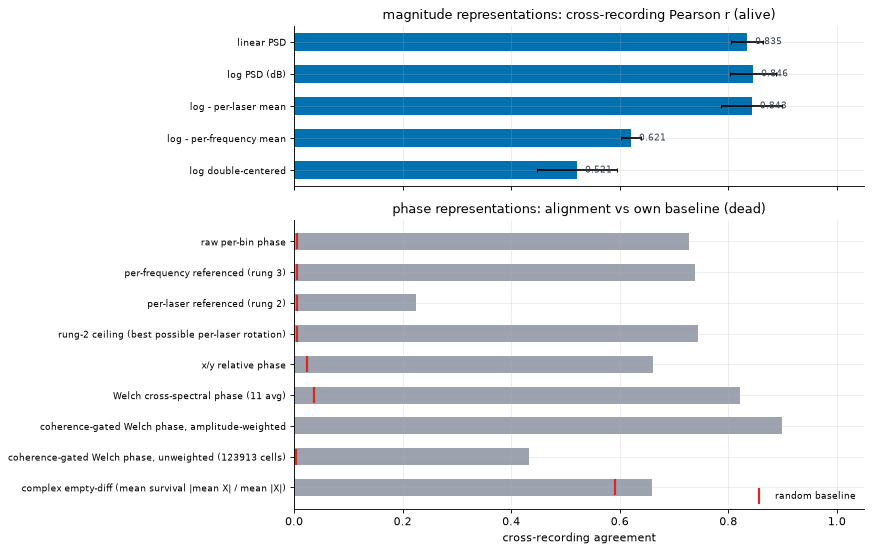

,mean,std
variant,,
linear PSD,0.835,0.029
log PSD (dB),0.846,0.042
log - per-laser mean,0.843,0.056
log - per-frequency mean,0.621,0.018
log double-centered,0.521,0.074


In [11]:
def variants(P):
    X = 10 * np.log10(P)
    return {'linear PSD': P, 'log PSD (dB)': X,
            'log - per-laser mean': X - X.mean(axis=2, keepdims=True),
            'log - per-frequency mean': X - X.mean(axis=0, keepdims=True),
            'log double-centered': X - X.mean(axis=2, keepdims=True) - X.mean(axis=0, keepdims=True) + X.mean(axis=(0, 2), keepdims=True)}

rows = []
for spk in SPEAKERS:
    for o1, o2 in avail_pairs(spk):
        va, vb = variants(pxx[(o1, spk)]), variants(pxx[(o2, spk)])
        for name in va:
            rows.append(dict(variant=name, r=float(np.corrcoef(va[name].ravel(), vb[name].ravel())[0, 1])))
mag_df = pd.DataFrame(rows).groupby('variant').r.agg(['mean', 'std']).reindex(list(variants(pxx[(OUTPUTS[0], 1)]).keys()))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, height_ratios=[len(mag_df), len(score_df)])
y0 = np.arange(len(mag_df))[::-1]
axes[0].barh(y0, mag_df['mean'], xerr=mag_df['std'], color=BLUE, height=0.55, capsize=2)
for yi, s in zip(y0, mag_df['mean']): axes[0].text(min(s + 0.015, 0.93), yi, f'{s:.3f}', va='center', fontsize=8, color='#374151')
axes[0].set_yticks(y0); axes[0].set_yticklabels(mag_df.index, fontsize=8)
axes[0].set_title('magnitude representations: cross-recording Pearson r (alive)')
y1 = np.arange(len(score_df))[::-1]
axes[1].barh(y1, score_df.score, color=RAW_GRAY, height=0.55)
axes[1].plot(score_df.random_baseline, y1, '|', color=RED, ms=14, mew=2, label='random baseline')
axes[1].set_yticks(y1); axes[1].set_yticklabels(score_df.method, fontsize=8)
axes[1].set_title('phase representations: alignment vs own baseline (dead)')
axes[1].set_xlim(0, 1.05); axes[1].set_xlabel('cross-recording agreement')
axes[1].legend(frameon=False, fontsize=8, loc='lower right')
fig.tight_layout(); plt.show()
mag_df.round(3)


## 7 · The phase payoff — mode-shape maps reproduce

The Bagon et al. Eq. 11 estimate $\Re\{G(x_n,\omega_k)\}/\overline{|G|}$ at a detected mode frequency should be a spatial map of the mode-shape gradient — the physical quantity their imaging pipeline is built on. On experiment-25 these maps were noise (r = 0.02 vs null −0.01, best 0.16): the phase loophole existed in principle but was starved of averages.

**Here it pays off.** Across all detected modes the map correlation averages 0.29 vs 0.06 for random bins, and the distribution is bimodal: the strong modes form a cluster at r ≈ 0.9. The top pairs — **speaker 8 @ 384 Hz (r = 0.94)**, speaker 7 @ 386 Hz (0.93), speaker 2 @ 558 Hz (0.93), speaker 3 @ 386/558/478 Hz (0.92) — reproduce almost exactly across recordings, visible by eye in the panels above. Even at ~11 Welch averages, this box yields usable mode-shape spatial structure; repeated-chirp excitation would sharpen the weak-mode majority that still scatters around zero.


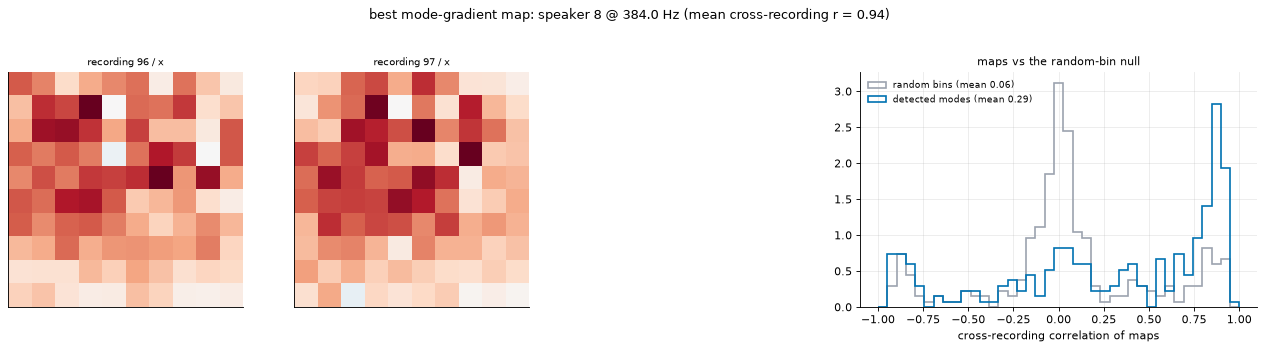

speaker  freq_hz
8        384.0      0.94
7        386.0      0.93
2        558.0      0.93
3        386.0      0.92
         558.0      0.92
         478.0      0.92
2        480.0      0.92
         598.0      0.91
6        402.0      0.89
3        404.0      0.89
Name: r, dtype: float64

In [12]:
GRID = (10, 10)  # n_laser_rows x n_laser_cols (src/model/dataset.py); row-major reshape assumed

def mode_map(out, spk, fi):
    Gf = welch[(out, spk)]['G'][:, :, fi].copy()
    Gf[REF_LASER[spk], 0] = 0
    return np.real(Gf) / max(np.abs(Gf).mean(), 1e-30)

cand = [(spk, f) for spk in SPEAKERS for f in repro[spk]] or [(8, 64.0), (7, 80.0), (4, 94.0)]
rng = np.random.default_rng(3)
mrows, null_r = [], []
for spk, f in cand:
    fi = int(np.argmin(np.abs(FW - f)))
    for o1, o2 in avail_pairs(spk):
        mrows.append(dict(speaker=spk, freq_hz=round(float(f), 1),
                          r=float(np.corrcoef(mode_map(o1, spk, fi).ravel(), mode_map(o2, spk, fi).ravel())[0, 1])))
        fj = int(rng.integers(len(FW)))
        null_r.append(float(np.corrcoef(mode_map(o1, spk, fj).ravel(), mode_map(o2, spk, fj).ravel())[0, 1]))
maps_rep = pd.DataFrame(mrows)
best = maps_rep.groupby(['speaker', 'freq_hz']).r.mean()
spk_b, f_b = best.idxmax()
fi_b = int(np.argmin(np.abs(FW - f_b)))

fig = plt.figure(figsize=(16, 4.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.6])
for j, out in enumerate(avail(int(spk_b))):
    ax = fig.add_subplot(gs[0, j])
    m = mode_map(out, int(spk_b), fi_b)[:, 0].reshape(GRID)
    vmax = np.percentile(np.abs(m), 99)
    ax.imshow(m, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'recording {out} / x', fontsize=9); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax = fig.add_subplot(gs[0, 3])
ax.hist(null_r, bins=np.linspace(-1, 1, 40), density=True, histtype='step', lw=1.5, color=RAW_GRAY, label=f'random bins (mean {np.mean(null_r):.2f})')
ax.hist(maps_rep.r, bins=np.linspace(-1, 1, 40), density=True, histtype='step', lw=1.5, color=BLUE, label=f'detected modes (mean {maps_rep.r.mean():.2f})')
ax.set_xlabel('cross-recording correlation of maps'); ax.legend(frameon=False, fontsize=8)
ax.set_title('maps vs the random-bin null', fontsize=10)
fig.suptitle(f'best mode-gradient map: speaker {int(spk_b)} @ {f_b} Hz (mean cross-recording r = {best.max():.2f})', y=1.03)
fig.tight_layout(); plt.show()
best.round(2).sort_values(ascending=False).head(10)


## The story in one paragraph

The experiment-24 metal empty box is a strongly modal, phase-stable scene: its magnitude spectrum reproduces to a median 0.21 dB; it has ~99 genuine resonant peaks (10–35σ above coincidence) shared across speakers (214 Hz in all 8); cross-recording **phase survives** (raw alignment 0.727 vs 0.006 chance, Welch cross-spectral phase 0.821); one cell in seven has genuine within-capture coherence; the double-centered content channel reproduces at r = 0.52; and Eq. 11 mode-shape maps reproduce at r up to 0.94. Every one of those statements was **false** on experiment-25 (notebook 52) except magnitude stability — same code, same nulls, opposite verdicts. Phase stability is therefore a property of the recording session/box, not of the method: something about experiment-25's captures (box, drift, or session procedure) re-randomized speckle phase between recordings, while experiment-24's did not.

**Consequences for the pipeline.** Log-magnitude (+ per-speaker empty-box log-spectrum subtraction) remains the safe representation that works on *both* datasets — but on experiment-24-like sessions, complex/phase features carry real signal: `--signal-mode complex` / `mag_phase` deserve a rematch on this data, and Welch cross-spectral phase and mode-gradient maps are viable features. One warning from chapter 6: on a strongly modal box, per-frequency centering removes real modal content (r 0.846 → 0.621), so normalize gently. **Consequences for the rerun**: repeated chirps with repetition period ≤ 0.5 s still buy ~10× more real looks per frequency bin — here they would sharpen the weak-mode maps rather than resurrect dead phase.

Next: Deck B — the same figures as paired comparisons (object-in-box vs empty), in notebook 54, once the object samples exist.
